In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import muon as mu
import anndata as ad
from scipy.io import mmread
import sys
import os
from pathlib import Path

%load_ext autoreload
%autoreload 2
%matplotlib inline

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

In [2]:
# --- Configuration ---

# Add project root to sys.path (important for notebooks to find 'src')
# This is a common pattern in notebooks to ensure imports work
# Find project root by searching for the directory containing 'src'
project_root = None
current_dir = Path.cwd()
# Check current dir and its parents for a 'src' subdirectory
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').is_dir():
        project_root = parent
        break

if project_root and str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"Added {project_root} to sys.path")
elif not project_root:
    print("Warning: Could not automatically find project root. Imports from src.* might fail.")
    print("Please ensure you run this notebook from the project root or add it to sys.path manually.")


try:
    # Import config module from the src package
    from src import config
    print("Successfully imported config from src")
except ImportError as e:
    print(f"Error importing config: {e}")
    print("Please check your project structure and ensure src/__init__.py exists.")

# Define the path to the specific mouse brain data subdirectory
# Use the DATA_DIR from config and join with the subdirectory name
# Since config.DATA_DIR is already a Path object, use the / operator
MOUSE_BRAIN_DATA_DIR = config.DATA_DIR / "mouse_brain_data"

# Now define your file paths using the MOUSE_BRAIN_DATA_DIR variable
RNA_COUNTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156610_brain.rna.counts.txt.gz"
ATAC_COUNTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.counts.txt.gz"
ATAC_PEAKS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.peaks.bed.gz"
CELLTYPE_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain_celltype.txt.gz"
ATAC_BARCODES_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.barcodes.txt.gz"
ATAC_FRAGMENTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.atac.fragments.sorted.bed.gz"

Added /nfs/home/students/l.reich/tangram to sys.path
Successfully imported config from src


In [3]:
# --- Configuration ---
#RNA_COUNTS_FILE = "../data/mouse_brain_data/GSM4156610_brain.rna.counts.txt.gz"
#ATAC_COUNTS_FILE = "../data/mouse_brain_data/GSM4156599_brain.counts.txt.gz" # Matrix Market sparse file
#ATAC_PEAKS_FILE = "../data/mouse_brain_data/GSM4156599_brain.peaks.bed.gz" # Peaks BED file
#CELLTYPE_FILE = "../data/mouse_brain_data/GSM4156599_brain_celltype.txt.gz" # Contains paired barcodes and cell types
#ATAC_BARCODES_FILE = "../data/mouse_brain_data/GSM4156599_brain.barcodes.txt.gz" # This file *should* contain barcodes corresponding to the Matrix columns

## scRNA

In [4]:
# Load the cell type/pairing file
# This file links ATAC and RNA barcodes for the paired cells (3293 cells)

df_celltype = pd.read_csv(CELLTYPE_FILE, sep='\t')

In [5]:
df_celltype = df_celltype.set_index('rna.bc')

In [6]:
# Get the list of paired RNA barcodes to use as common cell IDs

common_cell_ids = df_celltype.index.tolist()

In [7]:
# Load RNA counts matrix (Genes x Cells)

df_rna_counts = pd.read_csv(RNA_COUNTS_FILE, sep='\t', index_col=0)

In [8]:
# Clean the column names (cell barcodes) in the RNA counts DataFrame
# They use commas (,) but the celltype file uses periods (.)
# Replace commas with periods to match the common_cell_ids format

df_rna_counts.columns = df_rna_counts.columns.str.replace(',', '.', regex=False)

In [9]:
# Subset the RNA counts DataFrame to keep only the columns (cells) that are in our paired set
# This aligns the RNA data to the 3293 paired cells
# .reindex(columns=...) will select the columns and also handle cases where a barcode might be missing (inserts NaNs)
# We use .dropna(axis=1) to remove any columns that were entirely NaN if reindexing failed
df_rna_subset = df_rna_counts.reindex(columns=common_cell_ids).dropna(axis=1)

In [10]:
# Verify that the columns now exactly match the common cell IDs
if list(df_rna_subset.columns) != common_cell_ids:
     print("Error: Subsetting RNA counts failed to exactly match common cell IDs!")
     # Handle error - critical for alignment
else:
     print("RNA counts columns successfully subsetted and aligned to common cell IDs.")

RNA counts columns successfully subsetted and aligned to common cell IDs.


In [11]:
# Transpose the DataFrame to be Cells x Genes for AnnData
df_rna_transposed = df_rna_subset.T.copy() # Use .T for transpose and .copy()

In [12]:
# Create the AnnData object for RNA
# X: The transposed counts matrix (Paired_Cells x Genes)
# obs: Observation metadata (cells). Index should be the common cell IDs.
# var: Variable metadata (genes). Index should be the gene IDs.
adata_rna = ad.AnnData(
    X=df_rna_transposed,
    obs=pd.DataFrame(index=df_rna_transposed.index), # Use transposed index (common cell IDs) for obs names
    var=pd.DataFrame(index=df_rna_transposed.columns) # Use transposed columns (gene IDs) for var names
)

In [13]:
# Add cell type annotations to adata_rna.obs
# The index of adata_rna.obs is common_cell_ids (rna.bc)
# The index of df_celltype is also rna.bc
# Merge df_celltype (keeping only the 'celltype' column) into adata_rna.obs
adata_rna.obs = adata_rna.obs.merge(df_celltype[['celltype']], left_index=True, right_index=True, how='left')

## QC for RNA

Check for mitochondrial genes

In [14]:
adata_rna.var_names.str.startswith("Mt-").sum()

0

In [15]:
sc.pp.calculate_qc_metrics(
    adata_rna, inplace=True, log1p=True
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


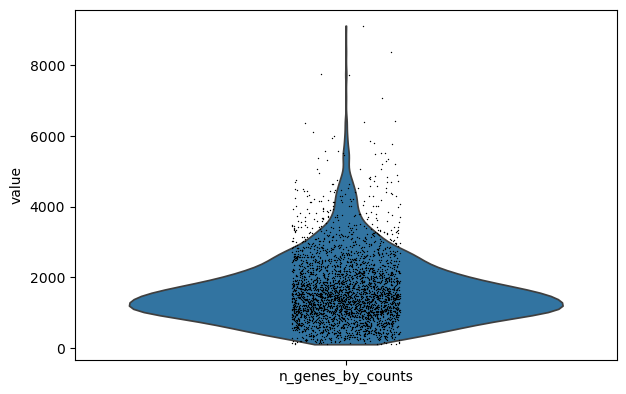

In [16]:
sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


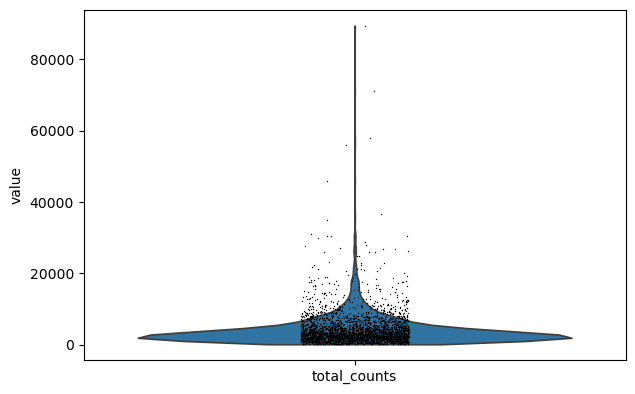

In [17]:
sc.pl.violin(
    adata_rna,
    ["total_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


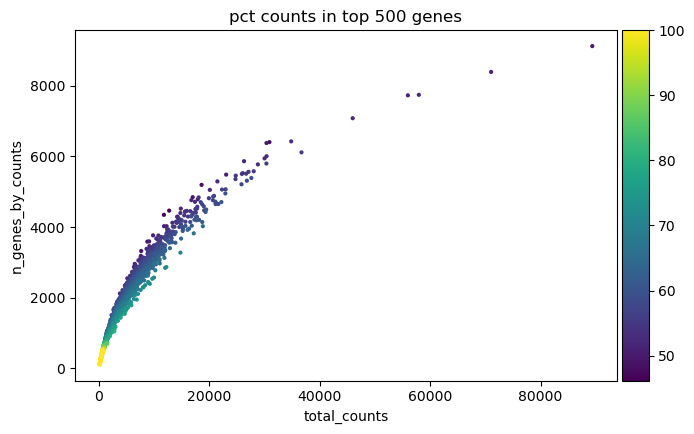

In [18]:
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_in_top_500_genes")

In [19]:
sc.pp.filter_cells(adata_rna, min_genes=100)

In [20]:
sc.pp.filter_genes(adata_rna, min_cells=2)

In [21]:
#sc.pp.scrublet(adata_rna, copy=True)

## Normalization

In [22]:
# Saving count data
adata_rna.layers["counts"] = adata_rna.X.copy()

In [23]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_rna)
# Logarithmize the data
sc.pp.log1p(adata_rna)

## Feature Selection

In [24]:
sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


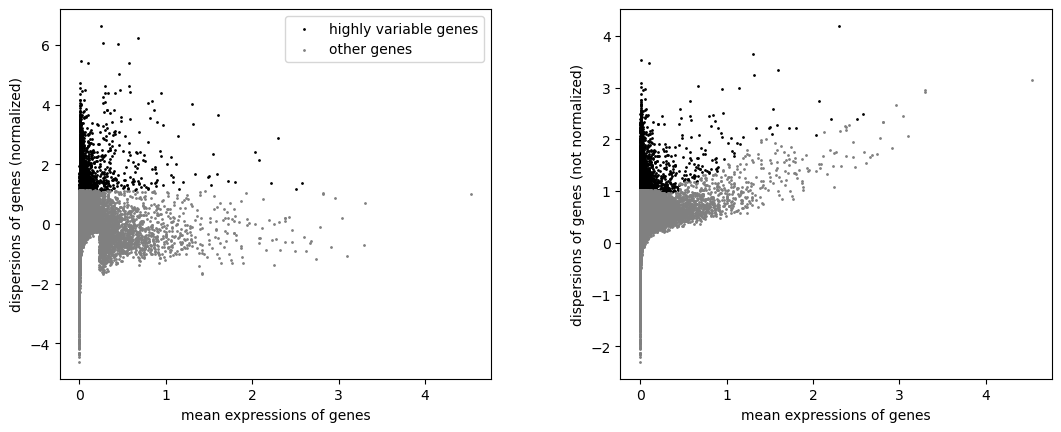

In [25]:
sc.pl.highly_variable_genes(adata_rna)

## Dimensionality Reduction

In [26]:
sc.tl.pca(adata_rna)

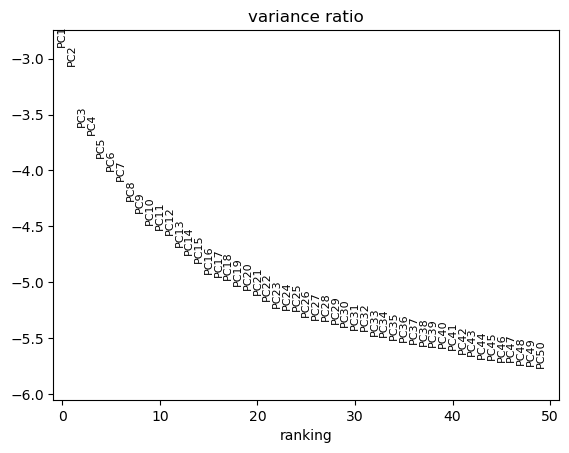

In [27]:
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50, log=True)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


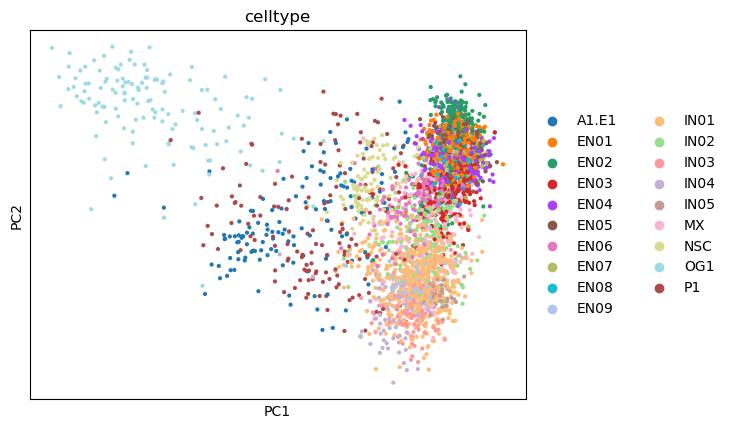

In [28]:
sc.pl.pca(
    adata_rna, color="celltype"
)

## scATAC

In [47]:
# Load the sparse matrix
matrix = mmread(ATAC_COUNTS_FILE).tocsc()

# Load barcodes and peaks
barcodes = pd.read_csv(ATAC_BARCODES_FILE, header=None)[0].tolist()
peaks = pd.read_csv(ATAC_PEAKS_FILE, sep='\t', header=None)
peaks['peak_id'] = peaks[0] + ':' + peaks[1].astype(str) + '-' + peaks[2].astype(str)
peak_ids = peaks['peak_id'].tolist()

# Create AnnData object
adata_atac = ad.AnnData(X=matrix.T)
adata_atac.obs_names = barcodes
adata_atac.var_names = peak_ids

In [48]:
mu.atac.tl.locate_fragments(adata_atac, str(ATAC_FRAGMENTS_FILE))

In [43]:
mdata = mu.MuData({'rna': adata_rna, 'atac': adata_atac})

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
